In [3]:
import control
import numpy as np
import matplotlib.pyplot as plt

In [2]:
num = [1]
den = [1, 2, 3, 2, 0]

System Analysis for G(s)
Rise Time: nan
Settling Time: nan
Overshoot: nan


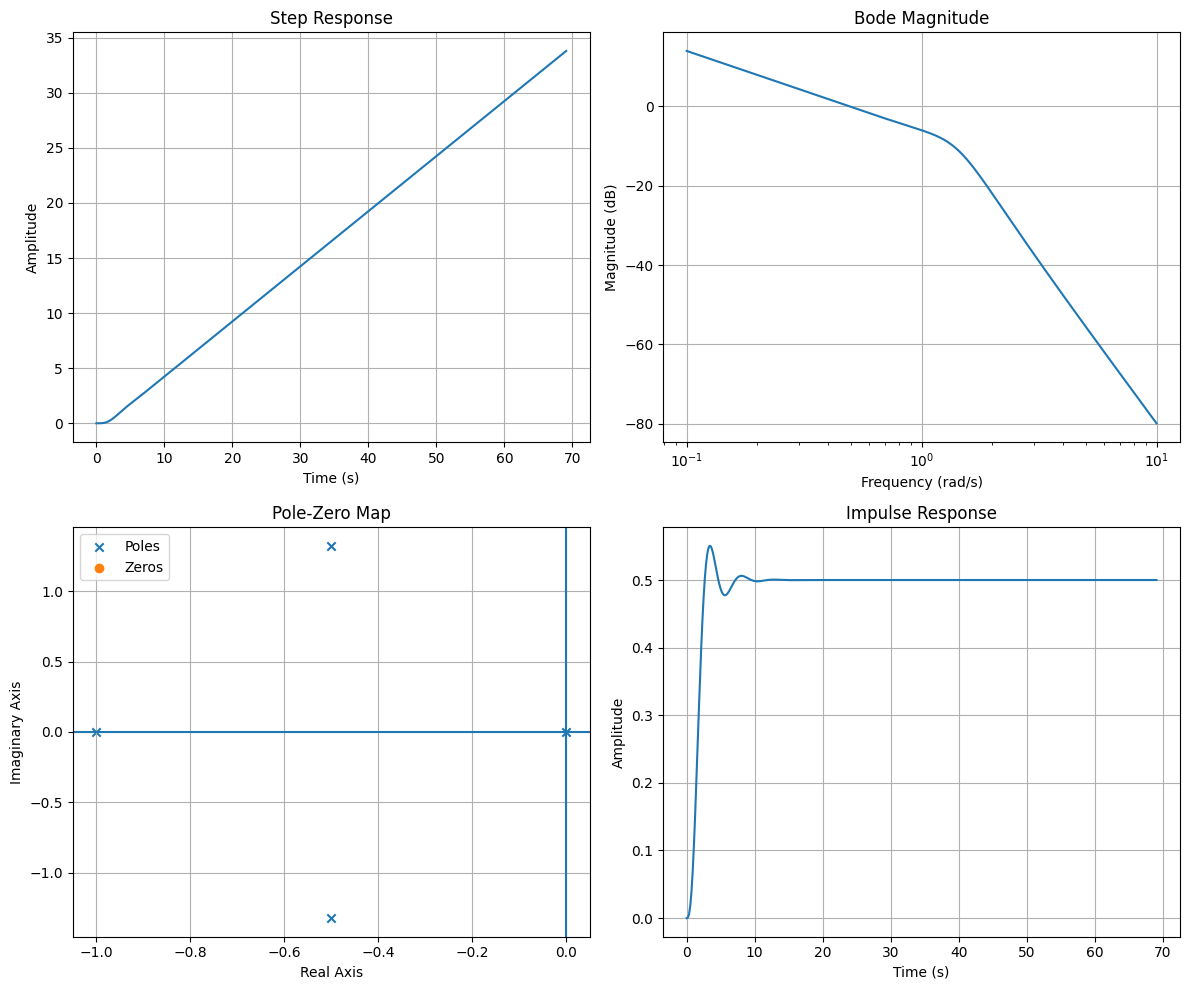

In [5]:
G_s = control.TransferFunction(num, den)

# Step response information
info = control.step_info(G_s)

print("System Analysis for G(s)")
print("Rise Time:", info['RiseTime'])
print("Settling Time:", info['SettlingTime'])
print("Overshoot:", info['Overshoot'])

# Create subplot grid
fig, axs = plt.subplots(2, 2, figsize=(12,10))

# 1️⃣ Step Response
t, y = control.step_response(G_s)
axs[0,0].plot(t, y)
axs[0,0].set_title("Step Response")
axs[0,0].set_xlabel("Time (s)")
axs[0,0].set_ylabel("Amplitude")
axs[0,0].grid(True)

# 2️⃣ Bode Plot (Magnitude)
mag, phase, omega = control.bode(G_s, plot=False)
axs[0,1].semilogx(omega, 20*np.log10(mag))
axs[0,1].set_title("Bode Magnitude")
axs[0,1].set_xlabel("Frequency (rad/s)")
axs[0,1].set_ylabel("Magnitude (dB)")
axs[0,1].grid(True)

# 3️⃣ Pole-Zero Map
poles = control.poles(G_s)
zeros = control.zeros(G_s)

axs[1,0].scatter(np.real(poles), np.imag(poles), marker='x', label='Poles')
axs[1,0].scatter(np.real(zeros), np.imag(zeros), marker='o', label='Zeros')
axs[1,0].axhline(0)
axs[1,0].axvline(0)
axs[1,0].set_title("Pole-Zero Map")
axs[1,0].set_xlabel("Real Axis")
axs[1,0].set_ylabel("Imaginary Axis")
axs[1,0].legend()
axs[1,0].grid(True)

# 4️⃣ Impulse Response
t_imp, y_imp = control.impulse_response(G_s)
axs[1,1].plot(t_imp, y_imp)
axs[1,1].set_title("Impulse Response")
axs[1,1].set_xlabel("Time (s)")
axs[1,1].set_ylabel("Amplitude")
axs[1,1].grid(True)

plt.tight_layout()
plt.show()